In [1]:
import pandas as pd
import os
import numpy as np
from tqdm.auto import tqdm

/home/t2/miniconda3/envs/tgn2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from collections import Counter

In [3]:
base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'wikipedia'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

/raid/t2/TGN_adv/sparsified_data/wikipedia/ml_wikipedia.csv


In [4]:
## Load original data

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.head()

,Unnamed: 0,u,i,ts,label,idx
0,0,1,8228,0.0,0.0,1
1,1,2,8229,36.0,0.0,2
2,2,2,8229,77.0,0.0,3
3,3,3,8230,131.0,0.0,4
4,4,2,8229,150.0,0.0,5


In [5]:
print(len(orig_df))

157474


In [6]:
# sparsification 
sprs_type = 'ts_tpr_remove_MSS'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)
print(full_sprs_filepath)

/raid/t2/TGN_adv/sparsified_data/wikipedia/ts_tpr_remove_MSS/wikipedia_ts_tpr_remove_MSS_sparsified_0.7.csv


In [7]:
df = pd.read_csv(full_sprs_filepath)
df.head()

,Unnamed: 0.1,Unnamed: 0,u,i,ts,label,idx
0,0,0,1,8228,0.0,0.0,1
1,1,29715,2745,8405,578300.0,0.0,29716
2,2,29720,2746,8882,578363.0,0.0,29721
3,3,29731,2747,8474,578507.0,0.0,29732
4,4,29752,2748,8688,578759.0,0.0,29753


In [69]:
print(len(df))

180945


#### Add early negative samples with C3 compliant

In [29]:
# from utils.utils import NegativeEdgeSampler
from utils.adv_utils import AdvNegativeEdgeSampler as NegativeEdgeSampler

negative_sample_strategy = 'random'
# negative_sample_strategy = 'historical'
# negative_sample_strategy = 'inductive'

In [7]:
# assert 0 == 1, 'INtentional'

In [8]:
start_time = df['ts'].iloc[0]
end_time = df['ts'].iloc[1]
start_time, end_time

(0.0, 578300.0)

In [9]:
len(orig_df['u'].unique()), len(orig_df['i'].unique())

(8227, 1000)

In [10]:
early_src_nodes = orig_df[orig_df['ts']<end_time]['u'].values
early_dst_nodes = orig_df[orig_df['ts']<end_time]['i'].values
early_interact_times = orig_df[orig_df['ts']<end_time]['ts'].values
len(np.unique(early_src_nodes)), len(np.unique(early_dst_nodes)), len(early_interact_times)

(2744, 707, 29715)

In [11]:
# [for u, i in orig_df[['u', 'i']].to_dict()['u'].items()]
set(list(orig_df[['u', 'i']].to_dict()['u'].items()))

{(23458, 2265),
 (36640, 2975),
 (15038, 1712),
 (17142, 1913),
 (9728, 380),
 (63723, 5),
 (11670, 977),
 (60030, 234),
 (88810, 309),
 (57256, 238),
 (28472, 2673),
 (134853, 7363),
 (79439, 500),
 (96281, 5759),
 (90801, 44),
 (27776, 1657),
 (58488, 3893),
 (35344, 624),
 (21669, 2233),
 (151949, 2366),
 (3785, 209),
 (80381, 5305),
 (50023, 3597),
 (24218, 798),
 (144632, 4149),
 (117842, 955),
 (124769, 2400),
 (1904, 238),
 (130066, 1992),
 (32874, 258),
 (113724, 1974),
 (9149, 272),
 (12891, 659),
 (10365, 11),
 (152226, 5468),
 (157326, 5300),
 (31890, 2747),
 (147149, 897),
 (92617, 1067),
 (76906, 135),
 (33797, 125),
 (12381, 1496),
 (154448, 6829),
 (91428, 2370),
 (41046, 1032),
 (85726, 780),
 (57720, 4263),
 (147940, 645),
 (51374, 1817),
 (134114, 1681),
 (140893, 222),
 (14193, 1646),
 (23339, 2276),
 (119577, 5180),
 (155546, 1974),
 (152125, 6863),
 (81235, 66),
 (62517, 2377),
 (98848, 4448),
 (58473, 871),
 (64916, 217),
 (2945, 487),
 (63886, 79),
 (105315, 401)

In [30]:
# what if last_observed_time < df['ts'].values[0]

In [35]:
negative_sample_strategy = 'random'

early_sampler = NegativeEdgeSampler(
        src_node_ids=early_src_nodes,
        dst_node_ids=early_dst_nodes,
        interact_times=early_interact_times, ## What if we give orig_df['ts'].values
        original_edges=set(list(orig_df[['u', 'i']].to_dict()['u'].items())),
        last_observed_time=end_time,
        negative_sample_strategy=negative_sample_strategy,
        seed=0
    )


neg_src, neg_dst = early_sampler.sample(
            size=10,
            batch_src_node_ids=np.array(early_src_nodes[0]),
            batch_dst_node_ids=early_dst_nodes,
            current_batch_start_time=start_time,
            current_batch_end_time=end_time
)

print(neg_src, neg_dst)
# [1 1 1 1 1 1 1 1 1 1] [8787 8857 8420 8587 8237 8505 8827 8298 8700 8828]

[1 1 1 1 1 1 1 1 1 1] [8912 8787 8857 8420 8587 8237 8505 8827 8298 8700]


In [64]:
len(orig_df), len(df)

(157474, 180945)

In [43]:
len(early_src_nodes), (len(set(early_src_nodes)))
type(early_src_nodes)


# Assuming early_src_nodes is your NumPy ndarray
unique_values, counts = np.unique(early_src_nodes, return_counts=True)

# Print the results
value_counts = dict(zip(unique_values, counts))
value_counts
len(value_counts)




# {1: 1,
#  2: 224,
#  3: 38,
#  4: 152,
#  5: 211,
#  6: 75,
#  7: 33,
#  8: 1,
#  9: 82}

2744

In [52]:
early_negative_samples_list = []


for u, count in tqdm(value_counts.items(), desc='Processing'):
    neg_src, neg_dst = early_sampler.sample(
            size=count,
            batch_src_node_ids=np.array(u),
            batch_dst_node_ids=early_dst_nodes,
            current_batch_start_time=start_time,
            current_batch_end_time=end_time
    )
    
    for src, dst in zip(neg_src, neg_dst):
            early_negative_samples_list.append([src, dst])
            



Processing: 100%|██████████| 2744/2744 [00:00<00:00, 38957.09it/s]


In [63]:
early_negative_samples_df = pd.DataFrame(early_negative_samples_list, columns=['u', 'i'])
early_negative_samples_df['ts'] = sorted(early_interact_times)
early_negative_samples_df

,u,i,ts
0,1,8365,0.0
1,2,8461,36.0
2,1,8332,77.0
3,2,8825,131.0
4,2,8435,150.0
...,...,...,...
29710,1614,8640,578277.0
29711,755,8786,578288.0
29712,2221,8759,578294.0
29713,1729,8343,578297.0


In [62]:
def add_negative_samples(df: pd.DataFrame, orig_df: pd.DataFrame, start_time: float, end_time: float, 
                         negative_sample_strategy: str = 'random', 
                         num_negative_samples: int = 1, 
                         seed: int = None,
                         time_window: float = 1200) -> pd.DataFrame:
    
    # first early missing points then remaining negative samples
    early_start_time = df['ts'].iloc[0]
    early_end_time = df['ts'].iloc[1]
    print(early_start_time, early_end_time)

In [14]:
# for u, i in zip(neg_src, neg_dst):
#     if len(orig_df[(orig_df['u']== u) & (orig_df['i']== i)]) != 0:
#         assert 0 == 1, 'break'
#     print(len(orig_df[(orig_df['u']== u) & (orig_df['i']== i)]))
# # These are true negative samples

,Unnamed: 0,u,i,ts,label,idx
232,232,58,8245,5056.0,0.0,233
261,261,58,8245,5800.0,0.0,262
316,316,77,8290,7296.0,0.0,317
387,387,77,8290,9298.0,0.0,388
413,413,77,8290,9943.0,0.0,414
...,...,...,...,...,...,...
156898,156898,77,8328,2664226.0,0.0,156899
157062,157062,77,8954,2668439.0,0.0,157063
157323,157323,77,8328,2674158.0,0.0,157324
157335,157335,77,8328,2674403.0,0.0,157336


In [71]:
import numpy as np
import pandas as pd

def sample_negative_edges_with_time_window(sparsified_graph, current_time, time_window, num_samples):
    """
    Sample negative edges from the remaining data of the sparsified graph,
    returning relevant timestamps that comply with the time window constraint.
    
    :param sparsified_graph: DataFrame containing the edges of the sparsified graph with timestamps.
    :param current_time: The current time at which we are sampling.
    :param time_window: The time window W within which we can sample edges.
    :param num_samples: The number of negative samples to generate.
    :return: List of tuples containing sampled negative edges and their timestamps.
    """
    # Extract relevant columns from the sparsified graph
    src_nodes = sparsified_graph['src'].values
    dst_nodes = sparsified_graph['dst'].values
    timestamps = sparsified_graph['ts'].values
    
    # Create a set of existing edges for quick lookup
    existing_edges = set(zip(src_nodes, dst_nodes))
    
    # Get the pool of potential source and destination nodes based on recent interactions
    recent_interactions = sparsified_graph[(timestamps <= current_time) & (timestamps > current_time - time_window)]
    
    # If there are no recent interactions, return empty list
    if recent_interactions.empty:
        return []

    recent_src_nodes = recent_interactions['src'].unique()
    recent_dst_nodes = recent_interactions['dst'].unique()
    
    negative_samples = []
    
    # Perform sampling
    while len(negative_samples) < num_samples:
        # Randomly sample source and destination from recent interactions
        neg_src_node = np.random.choice(recent_src_nodes)
        neg_dst_node = np.random.choice(recent_dst_nodes)

        # Ensure that the sampled nodes are not the same and the edge does not exist
        if neg_src_node != neg_dst_node and (neg_src_node, neg_dst_node) not in existing_edges:
            # Generate a timestamp that falls within the time window
            neg_timestamp = np.random.randint(current_time - time_window, current_time + 1)  # Inclusive of current_time
            
            # Append the negative edge along with its timestamp
            negative_samples.append((neg_src_node, neg_dst_node, neg_timestamp))

    return negative_samples

# Example usage
current_time = 100  # Example current time
time_window = 10    # Example time window
num_samples = 50    # Number of negative samples to generate

# Assuming sparsified_graph is a DataFrame with columns ['src', 'dst', 'ts']
sparsified_graph = pd.DataFrame({
    'src': [1, 2, 3, 1, 4],
    'dst': [2, 3, 4, 3, 5],
    'ts': [90, 91, 92, 95, 98]
})

negative_samples = sample_negative_edges_with_time_window(sparsified_graph, current_time, time_window, num_samples)
print("Sampled Negative Edges with Timestamps:", negative_samples)

Sampled Negative Edges with Timestamps: [(2, 4, 99), (1, 5, 99), (2, 5, 96), (4, 3, 99), (3, 5, 100), (1, 5, 96), (2, 5, 91), (3, 5, 95), (3, 5, 90), (3, 5, 94), (1, 5, 97), (3, 5, 91), (1, 5, 100), (1, 4, 95), (3, 5, 95), (1, 5, 96), (3, 5, 95), (1, 5, 92), (4, 3, 93), (2, 5, 95), (4, 3, 94), (1, 5, 94), (2, 5, 90), (1, 5, 100), (4, 3, 92), (3, 5, 97), (1, 5, 100), (4, 3, 93), (3, 5, 99), (2, 4, 91), (1, 4, 100), (1, 4, 93), (2, 5, 95), (4, 3, 93), (2, 4, 98), (2, 5, 90), (1, 4, 98), (1, 5, 99), (4, 3, 95), (2, 4, 91), (1, 4, 99), (2, 4, 100), (2, 5, 90), (1, 5, 93), (1, 5, 94), (4, 3, 100), (4, 3, 93), (2, 4, 92), (2, 5, 97), (2, 5, 96)]


In [ ]:
orig_df[(orig_df['i'].isin(neg_dst))]

,Unnamed: 0,u,i,ts,label,idx
87,87,33,8260,2053.0,1.0,88
389,389,94,8308,9307.0,0.0,390
437,437,94,8308,10614.0,0.0,438
970,970,204,8260,25830.0,0.0,971
975,975,204,8260,25974.0,0.0,976
...,...,...,...,...,...,...
150184,150184,94,8308,2514190.0,0.0,150185
150450,150450,7959,8308,2521568.0,0.0,150451
152940,152940,94,8308,2573939.0,0.0,152941
155890,155890,94,8308,2645576.0,0.0,155891


In [72]:
df.head()

,Unnamed: 0.1,Unnamed: 0,u,i,ts,label,idx
0,0,0,1,8228,0.0,0.0,1
1,1,29715,2745,8405,578300.0,0.0,29716
2,2,29720,2746,8882,578363.0,0.0,29721
3,3,29731,2747,8474,578507.0,0.0,29732
4,4,29752,2748,8688,578759.0,0.0,29753


In [76]:
negative_sample_strategy = 'random'

early_sampler = NegativeEdgeSampler(
        src_node_ids=df['u'].values,
        dst_node_ids=df['i'].values,
        interact_times=df['ts'].values, ## What if we give orig_df['ts'].values
        # original_edges=set(list(orig_df[['u', 'i']].to_dict()['u'].items())),
        last_observed_time=max(df['ts'].values),
        negative_sample_strategy=negative_sample_strategy,
        seed=0
    )


neg_src, neg_dst = early_sampler.sample(
            size=10,
            batch_src_node_ids=df['u'].values,
            batch_dst_node_ids=df['i'].values,
            current_batch_start_time=min(0, (df['ts'].values)),
            current_batch_end_time=max(df['ts'].values)
)

print(neg_src, neg_dst)

[1875 2659  442  156 4307 5492  891  489  115 5191] [8919 8793 8864 8422 9073 9000 8943 8591 8237 8959]


In [80]:
from collections import deque

In [78]:
df_sorted = df.sort_values('ts').reset_index(drop=True)
df_sorted

,Unnamed: 0.1,Unnamed: 0,u,i,ts,label,idx
0,0,0,1,8228,0.0,0.0,1
1,1,29715,2745,8405,578300.0,0.0,29716
2,2,29720,2746,8882,578363.0,0.0,29721
3,3,29731,2747,8474,578507.0,0.0,29732
4,4,29752,2748,8688,578759.0,0.0,29753
...,...,...,...,...,...,...,...
180940,180940,157471,2400,8723,2678293.0,0.0,157472
180941,180941,157472,7480,9148,2678333.0,0.0,157473
180942,180942,157472,7480,9148,2678333.0,0.0,157473
180943,180943,157473,2400,8723,2678373.0,0.0,157474


In [79]:
sampler = NegativeEdgeSampler(
        src_node_ids=df_sorted['u'].values,
        dst_node_ids=df_sorted['i'].values,
        interact_times=df_sorted['ts'].values,
        last_observed_time=max(df_sorted['ts'].values),
        negative_sample_strategy=negative_sample_strategy,
        seed=0
    )

In [102]:
rng = np.random.default_rng(0)
negative_samples = []

# Calculate the number of batches
batch_size = 10000  # You can adjust this based on your memory constraints
num_batches = len(df_sorted) // batch_size + (1 if len(df_sorted) % batch_size != 0 else 0)

for batch in tqdm(range(num_batches), desc='Generating neg samples', leave=False, ncols=100):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(df_sorted))
    
    batch_df = df_sorted.iloc[start_idx:end_idx]
    
    neg_src, neg_dst = sampler.sample(
        size=1,
        batch_src_node_ids=batch_df['u'].values,
        batch_dst_node_ids=batch_df['i'].values,
        current_batch_start_time=min(start_time, batch_df['ts'].min()),
        current_batch_end_time=min(end_time, batch_df['ts'].max())
    )
    
    for i in range(len(neg_src)):
        row_idx = i // 1
        row = batch_df.iloc[row_idx]
        neg_ts = max(start_time, min(end_time, int(rng.uniform(row['ts'] - time_window, row['ts']))))
        
        negative_samples.append({
            'u': neg_src[i],
            'i': neg_dst[i],
            'ts': neg_ts,
            'is_negative': 1,
        })

In [96]:
negative_samples

[{'u': 5138, 'i': 8258, 'ts': 0.0, 'is_negative': 1},
 {'u': 1492, 'i': 8910, 'ts': 578300.0, 'is_negative': 1},
 {'u': 1930, 'i': 8424, 'ts': 578300.0, 'is_negative': 1},
 {'u': 6376, 'i': 8491, 'ts': 578300.0, 'is_negative': 1},
 {'u': 413, 'i': 8246, 'ts': 578300.0, 'is_negative': 1},
 {'u': 386, 'i': 8970, 'ts': 578300.0, 'is_negative': 1},
 {'u': 2057, 'i': 8343, 'ts': 578300.0, 'is_negative': 1},
 {'u': 1595, 'i': 8779, 'ts': 578300.0, 'is_negative': 1},
 {'u': 592, 'i': 8588, 'ts': 578300.0, 'is_negative': 1},
 {'u': 2546, 'i': 8474, 'ts': 578300.0, 'is_negative': 1},
 {'u': 6360, 'i': 8801, 'ts': 578300.0, 'is_negative': 1},
 {'u': 90, 'i': 8377, 'ts': 578300.0, 'is_negative': 1},
 {'u': 2149, 'i': 9055, 'ts': 578300.0, 'is_negative': 1},
 {'u': 1571, 'i': 9076, 'ts': 578300.0, 'is_negative': 1},
 {'u': 820, 'i': 8938, 'ts': 578300.0, 'is_negative': 1},
 {'u': 418, 'i': 8456, 'ts': 578300.0, 'is_negative': 1},
 {'u': 6796, 'i': 9015, 'ts': 578300.0, 'is_negative': 1},
 {'u': 25

In [9]:
check_df = pd.read_csv(r'./testing.csv')
# check_df = check_df[check_df['is_negative'] == 1]
check_df = check_df.drop(['Unnamed: 0'], axis=1)
check_df = check_df.sort_values(['u', 'ts'])
check_df.head()

,u,i,ts,label,idx,is_negative
0,1,8787,0.0,0.0,1.0,1
7,1,8420,77.0,0.0,3.0,1
8,1,8587,131.0,0.0,4.0,1
14,1,8828,242.0,0.0,10.0,1
17,1,8714,376.0,0.0,13.0,1


In [14]:
# check_df['diff'] = check_df.groupby('u')['ts'].diff()
# check_df

In [21]:
# check_df['ts'].isna().sum() # No nans

In [25]:
check_df['diff'] = check_df.groupby('u')['ts'].diff().fillna(0)
check_df

,u,i,ts,label,idx,is_negative,diff
0,1,8787,0.0,0.0,1.0,1,0.0
7,1,8420,77.0,0.0,3.0,1,77.0
8,1,8587,131.0,0.0,4.0,1,54.0
14,1,8828,242.0,0.0,10.0,1,111.0
17,1,8714,376.0,0.0,13.0,1,134.0
...,...,...,...,...,...,...,...
75637,6519,9167,1858111.0,0.0,110005.0,0,21.0
75723,6520,9167,1860373.0,0.0,110116.0,0,0.0
75725,6521,9134,1860505.0,0.0,110121.0,0,0.0
75757,6522,9046,1861478.0,0.0,110162.0,0,0.0


In [26]:
check_df[check_df['diff'] > 1200]

,u,i,ts,label,idx,is_negative,diff
983,1,8768,26102.0,0.0,979.0,1,3078.0
1201,1,8617,33181.0,0.0,1197.0,1,2393.0
1365,1,8818,37879.0,0.0,1361.0,1,1751.0
1474,1,8696,42002.0,0.0,1469.0,1,1712.0
1591,1,8751,45270.0,0.0,1587.0,1,2580.0
...,...,...,...,...,...,...,...
75377,6504,8350,1851033.0,0.0,109650.0,0,1704.0
75502,6504,8350,1853561.0,0.0,109795.0,0,1640.0
75654,6504,8350,1858458.0,0.0,110024.0,0,2311.0
75567,6511,8772,1855278.0,0.0,109894.0,0,2080.0


In [27]:
check_df['diff'].max()

1491695.0

In [39]:
orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df = orig_df.drop(['Unnamed: 0'], axis=1)
check_df = check_df.sort_values(['u', 'ts'])

orig_df['diff'] = orig_df.groupby(['u', 'i'])['ts'].diff().fillna(0)

orig_df.head()

,u,i,ts,label,idx,diff
0,1,8228,0.0,0.0,1,0.0
1,2,8229,36.0,0.0,2,0.0
2,2,8229,77.0,0.0,3,41.0
3,3,8230,131.0,0.0,4,0.0
4,2,8229,150.0,0.0,5,73.0


In [42]:
orig_df[orig_df['diff'] == orig_df['diff'].max()]

,u,i,ts,label,idx,diff
153095,250,8278,2576342.0,0.0,153096,2542699.0


In [44]:
orig_df['diff'].median(), orig_df['diff'].max(), orig_df['diff'].min()

(215.0, 2542699.0, 0.0)

Text(0.5, 1.0, 'Histogram of Time Differences Between Consecutive Interactions')

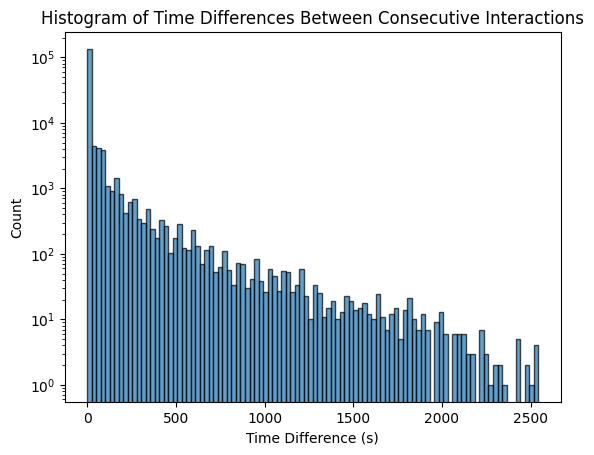

In [58]:
import matplotlib.pyplot as plt

ts_diffs = orig_df['diff'].dropna()
# ts_diffs

# Calculate statistics
mean_diff = ts_diffs.mean()
median_diff = ts_diffs.median()
std_diff = ts_diffs.std()

plt.hist(ts_diffs/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
plt.ylabel('Count')
plt.xlabel('Time Difference (s)')
plt.title('Histogram of Time Differences Between Consecutive Interactions')

Text(0.5, 1.0, 'Histogram of Time Differences Between Consecutive Interactions')

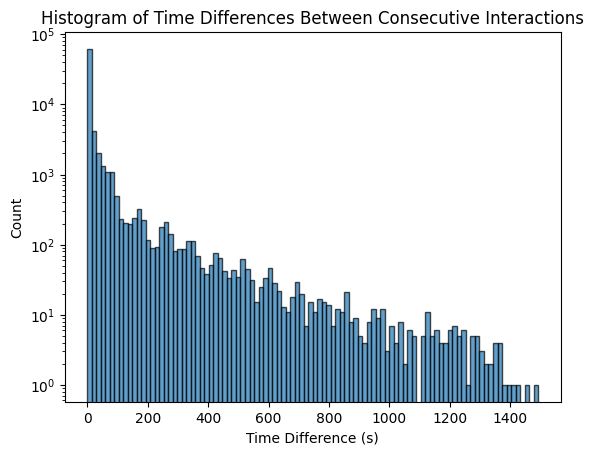

In [57]:
import matplotlib.pyplot as plt

ts_diffs = check_df['diff'].dropna()
# ts_diffs

# Calculate statistics
mean_diff = ts_diffs.mean()
median_diff = ts_diffs.median()
std_diff = ts_diffs.std()

plt.hist(ts_diffs/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
plt.ylabel('Count')
plt.xlabel('Time Difference (s)')
plt.title('Histogram of Time Differences Between Consecutive Interactions')

In [6]:
# check degree of nodes in sparsified and original df

orig_df.head()



,Unnamed: 0,u,i,ts,label,idx
0,0,1,8228,0.0,0.0,1
1,1,2,8229,36.0,0.0,2
2,2,2,8229,77.0,0.0,3
3,3,3,8230,131.0,0.0,4
4,4,2,8229,150.0,0.0,5


In [8]:
df.head()

,Unnamed: 0.1,Unnamed: 0,u,i,ts,label,idx
0,0,0,1,8228,0.0,0.0,1
1,1,29715,2745,8405,578300.0,0.0,29716
2,2,29720,2746,8882,578363.0,0.0,29721
3,3,29731,2747,8474,578507.0,0.0,29732
4,4,29752,2748,8688,578759.0,0.0,29753


In [9]:
def compute_overall_outgoing_degree(E):
    return Counter(E['u'])

In [10]:
node_degree_orig = compute_overall_outgoing_degree(orig_df[['u', 'i']])
node_degree_orig

Counter({1: 1,
         2: 285,
         3: 162,
         4: 189,
         5: 656,
         6: 271,
         7: 272,
         8: 44,
         9: 286,
         10: 58,
         11: 109,
         12: 5,
         13: 279,
         14: 151,
         15: 49,
         16: 9,
         17: 108,
         18: 588,
         19: 167,
         20: 2,
         21: 2,
         22: 4,
         23: 127,
         24: 7,
         25: 111,
         26: 70,
         27: 10,
         28: 295,
         29: 8,
         30: 1,
         31: 4,
         32: 8,
         33: 1,
         34: 23,
         35: 5,
         36: 7,
         37: 332,
         38: 3,
         39: 1,
         40: 269,
         41: 231,
         42: 10,
         43: 43,
         44: 31,
         45: 36,
         46: 43,
         47: 102,
         48: 280,
         49: 112,
         50: 33,
         51: 178,
         52: 291,
         53: 16,
         54: 19,
         55: 20,
         56: 4,
         57: 179,
         58: 7,
         59: 100

In [14]:
node_degree_sprs = compute_overall_outgoing_degree(df[['u', 'i']])
node_degree_sprs

Counter({1: 1,
         2745: 9,
         2746: 1,
         2747: 204,
         2748: 1,
         2749: 7,
         2750: 2,
         2751: 1,
         2752: 1,
         2753: 2,
         2755: 1,
         2756: 4,
         2757: 1,
         2758: 1,
         2759: 1,
         2760: 1,
         2761: 1,
         2763: 1,
         2764: 1,
         2765: 5,
         2766: 1,
         2767: 1,
         2768: 1,
         2769: 1,
         2770: 153,
         2771: 1,
         2772: 2,
         2773: 1,
         2774: 1,
         2775: 1,
         2776: 6,
         2777: 7,
         2778: 67,
         2779: 1,
         2780: 1,
         2781: 1,
         2782: 35,
         2783: 2,
         2784: 81,
         2785: 3,
         2786: 1,
         2787: 3,
         2788: 1,
         2789: 412,
         2790: 1,
         2791: 39,
         2792: 1,
         2793: 1,
         2794: 1,
         2795: 79,
         2796: 1,
         2797: 1,
         2798: 32,
         2799: 1,
         2800: 1,
 

In [22]:
node_degree_attack = compute_overall_outgoing_degree(check_df[['u', 'i']])
node_degree_attack

Counter({1: 319,
         2: 386,
         3: 223,
         4: 195,
         5: 458,
         6: 113,
         7: 328,
         8: 128,
         9: 205,
         10: 131,
         11: 97,
         12: 97,
         13: 201,
         14: 122,
         15: 83,
         16: 66,
         17: 95,
         18: 294,
         19: 156,
         20: 70,
         21: 70,
         22: 67,
         23: 92,
         24: 64,
         25: 138,
         26: 101,
         27: 75,
         28: 174,
         29: 74,
         30: 49,
         31: 60,
         32: 61,
         33: 52,
         34: 86,
         35: 61,
         36: 61,
         37: 225,
         38: 61,
         39: 52,
         40: 190,
         41: 133,
         42: 68,
         43: 79,
         44: 49,
         45: 59,
         46: 78,
         47: 45,
         48: 210,
         49: 109,
         50: 78,
         51: 79,
         52: 157,
         53: 51,
         54: 45,
         55: 54,
         56: 55,
         57: 181,
         58: 50,

In [27]:
for node, degree in node_degree_orig.items():
    print(f'For {node = } original {degree = }, sparsified degree {node_degree_sprs.get(node, -np.inf)}', end=' ')
    print(f'In attacked data degree {node_degree_attack.get(node, -np.inf)}')
    

For node = 1 original degree = 1, sparsified degree 1 In attacked data degree 319
For node = 2 original degree = 285, sparsified degree 54 In attacked data degree 386
For node = 3 original degree = 162, sparsified degree 200 In attacked data degree 223
For node = 4 original degree = 189, sparsified degree 49 In attacked data degree 195
For node = 5 original degree = 656, sparsified degree 675 In attacked data degree 458
For node = 6 original degree = 271, sparsified degree 304 In attacked data degree 113
For node = 7 original degree = 272, sparsified degree 136 In attacked data degree 328
For node = 8 original degree = 44, sparsified degree 57 In attacked data degree 128
For node = 9 original degree = 286, sparsified degree 265 In attacked data degree 205
For node = 10 original degree = 58, sparsified degree 65 In attacked data degree 131
For node = 11 original degree = 109, sparsified degree 3 In attacked data degree 97
For node = 12 original degree = 5, sparsified degree -inf In atta

In [34]:
# len(orig_df), len(df), len(att_df)

In [31]:
raid_path = r'/raid/t2/TGN_adv/poisoned_data/nss_random/wikipedia/ts_tpr_remove_MSS'
file_path = 'wikipedia_ts_tpr_remove_MSS_sparsified_0.7.csv'

att_df = pd.read_csv(os.path.join(raid_path, file_path))
att_df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)

In [32]:
att_df.head()

,u,i,ts,label,idx,is_negative
0,1,8787,0.0,0.0,1.0,1.0
1,2,8857,36.0,0.0,2.0,1.0
2,2,8420,77.0,0.0,3.0,1.0
3,2,8587,131.0,0.0,4.0,1.0
4,2,8237,150.0,0.0,5.0,1.0


Text(0.5, 1.0, 'Histogram of Time Differences Between Consecutive Interactions')

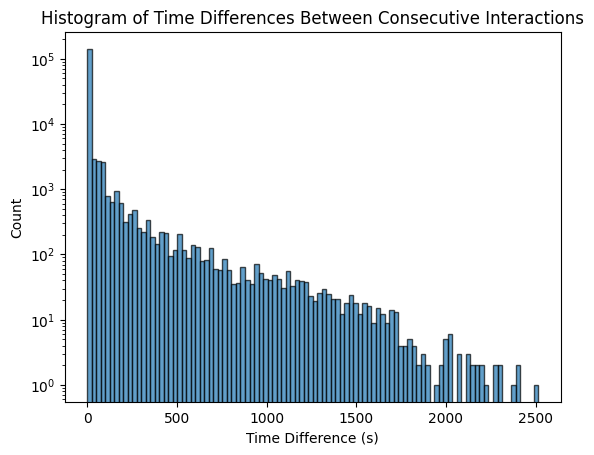

In [36]:
import matplotlib.pyplot as plt

# orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
# orig_df = orig_df.drop(['Unnamed: 0'], axis=1)
att_df = att_df.sort_values(['u', 'ts'])

att_df['diff'] = att_df.groupby(['u', 'i'])['ts'].diff().fillna(0)

ts_diffs = att_df['diff'].dropna()
# ts_diffs

# Calculate statistics
mean_diff = ts_diffs.mean()
median_diff = ts_diffs.median()
std_diff = ts_diffs.std()

plt.hist(ts_diffs/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
plt.ylabel('Count')
plt.xlabel('Time Difference (s)')
plt.title('Histogram of Time Differences Between Consecutive Interactions')

In [38]:
node_degree_attack = compute_overall_outgoing_degree(att_df[['u', 'i']])
node_degree_attack

Counter({1: 334,
         2: 523,
         3: 433,
         4: 307,
         5: 694,
         6: 427,
         7: 393,
         8: 284,
         9: 308,
         10: 253,
         11: 185,
         12: 144,
         13: 274,
         14: 265,
         15: 174,
         16: 119,
         17: 173,
         18: 528,
         19: 310,
         20: 139,
         21: 103,
         22: 104,
         23: 186,
         24: 140,
         25: 193,
         26: 209,
         27: 126,
         28: 193,
         29: 136,
         30: 102,
         31: 95,
         32: 94,
         33: 98,
         34: 99,
         35: 90,
         36: 89,
         37: 334,
         38: 140,
         39: 83,
         40: 290,
         41: 305,
         42: 137,
         43: 98,
         44: 103,
         45: 118,
         46: 119,
         47: 172,
         48: 264,
         49: 234,
         50: 113,
         51: 183,
         52: 280,
         53: 101,
         54: 66,
         55: 77,
         56: 72,
         57:

In [42]:
cnt = 0
for node, degree in node_degree_orig.items():
    if degree != node_degree_attack.get(node, -np.inf):
        cnt+=1
        print(f'For {node = } original {degree = }', end=' ')
        print(f'In attacked data degree {node_degree_attack.get(node, -np.inf)}')

For node = 1 original degree = 1 In attacked data degree 334
For node = 2 original degree = 285 In attacked data degree 523
For node = 3 original degree = 162 In attacked data degree 433
For node = 4 original degree = 189 In attacked data degree 307
For node = 5 original degree = 656 In attacked data degree 694
For node = 6 original degree = 271 In attacked data degree 427
For node = 7 original degree = 272 In attacked data degree 393
For node = 8 original degree = 44 In attacked data degree 284
For node = 9 original degree = 286 In attacked data degree 308
For node = 10 original degree = 58 In attacked data degree 253
For node = 11 original degree = 109 In attacked data degree 185
For node = 12 original degree = 5 In attacked data degree 144
For node = 13 original degree = 279 In attacked data degree 274
For node = 14 original degree = 151 In attacked data degree 265
For node = 15 original degree = 49 In attacked data degree 174
For node = 16 original degree = 9 In attacked data degre

In [44]:
cnt, len(node_degree_orig.items())

(4698, 8227)

In [45]:
len(node_degree_orig.items()), len(node_degree_attack.items())  # there are few nodes(403) missing
len(set(list(node_degree_orig.keys())).difference(list(node_degree_attack.keys()))) # <==== missing keys


(8227, 7824)

In [53]:
# max(list(node_degree_orig.keys())), max(list(node_degree_attack.keys()))
missing_keys = (set(list(node_degree_orig.keys())).difference(list(node_degree_attack.keys())))

# these have degree < 10, why algorithm is removing them. I am only removing important edges.
# Maybe timestamp is important too. if we keep same degree but we include (negatively sampled) edges at different timestamp, would it hamper performance? 

for key in missing_keys:
    print(f'Original degree of node {key} {node_degree_orig.get(key, -np.inf)}, while in attacked degree becomes {node_degree_attack.get(key, -np.inf)}')

Original degree of node 1126 8, while in attacked degree becomes -inf
Original degree of node 1516 1, while in attacked degree becomes -inf
Original degree of node 1519 14, while in attacked degree becomes -inf
Original degree of node 1580 2, while in attacked degree becomes -inf
Original degree of node 1581 1, while in attacked degree becomes -inf
Original degree of node 1621 4, while in attacked degree becomes -inf
Original degree of node 1665 2, while in attacked degree becomes -inf
Original degree of node 1694 4, while in attacked degree becomes -inf
Original degree of node 1700 5, while in attacked degree becomes -inf
Original degree of node 1729 2, while in attacked degree becomes -inf
Original degree of node 1731 1, while in attacked degree becomes -inf
Original degree of node 1742 2, while in attacked degree becomes -inf
Original degree of node 1743 5, while in attacked degree becomes -inf
Original degree of node 1749 1, while in attacked degree becomes -inf
Original degree of 

In [1]:
# how do I generate negative samples such that the node degree remains consistent?
# Then where should I place them in w.r.t. timestamps while respecting C3 timestamps.
# C3 constraint restricts the arbitrary placement of negatively sampled edges.

In [26]:
# new_path = '/raid/t2/TGN_adv//poisoned_data/nss_random/wikipedia/ts_tpr_remove_MSS'
new_path = '/raid/t2/TGN_adv//poisoned_data/nss_historical/wikipedia/ts_tpr_remove_MSS'
filename = 'wikipedia_ts_tpr_remove_MSS_sparsified_0.7.csv'

new_filepath = os.path.join(new_path, filename)
new_filepath

'/raid/t2/TGN_adv//poisoned_data/nss_historical/wikipedia/ts_tpr_remove_MSS/wikipedia_ts_tpr_remove_MSS_sparsified_0.7.csv'

In [27]:
new_attacked_df = pd.read_csv(new_filepath)
new_attacked_df.drop(['Unnamed: 0'], axis=1, inplace=True)
new_attacked_df.head()

,u,i,ts,label,idx,is_negative
0,1,8228,0.000000,0.0,1.0,NaN
1,4946,8615,10.655030,NaN,NaN,1.0
2,2,8857,36.000000,0.0,2.0,1.0
3,2,8420,77.000000,0.0,3.0,1.0
4,477,8639,122.689164,NaN,NaN,1.0


In [13]:
new_attacked_df['ts'].min()

0.0

In [28]:
node_degree_attack = compute_overall_outgoing_degree(new_attacked_df[['u', 'i']])
node_degree_attack

Counter({1: 1,
         4946: 11,
         2: 264,
         477: 620,
         560: 239,
         704: 32,
         5959: 7,
         1221: 126,
         763: 81,
         347: 1044,
         7: 268,
         729: 20,
         13: 289,
         260: 169,
         221: 279,
         1570: 61,
         418: 480,
         1322: 353,
         672: 313,
         227: 160,
         1829: 113,
         4504: 77,
         6: 343,
         2186: 98,
         1864: 104,
         52: 392,
         726: 32,
         125: 1390,
         1258: 992,
         829: 444,
         1183: 442,
         3: 97,
         405: 139,
         6450: 5,
         1088: 2142,
         80: 68,
         225: 367,
         1075: 716,
         2317: 16,
         688: 21,
         411: 455,
         3080: 11,
         1280: 162,
         6180: 391,
         5: 736,
         120: 299,
         1271: 36,
         243: 67,
         5523: 15,
         3044: 19,
         579: 140,
         1630: 151,
         4086: 250,
     

In [15]:
check = new_attacked_df[new_attacked_df['ts'] < 578300.0]

In [16]:
# check
node_degree_check = compute_overall_outgoing_degree(check[['u', 'i']])
node_degree_check

Counter({1827: 13,
         1: 1,
         2491: 1,
         2479: 54,
         1088: 284,
         2: 100,
         3253: 43,
         616: 107,
         1014: 16,
         609: 61,
         6404: 2,
         1374: 43,
         6853: 6,
         2698: 37,
         52: 56,
         833: 4,
         336: 56,
         2947: 7,
         513: 57,
         1317: 35,
         1170: 2,
         1822: 31,
         4646: 9,
         404: 30,
         441: 17,
         3257: 1,
         215: 77,
         4460: 4,
         715: 48,
         1280: 23,
         69: 107,
         1644: 23,
         1552: 41,
         260: 29,
         41: 52,
         1667: 14,
         4842: 5,
         483: 18,
         5059: 2,
         7577: 26,
         383: 62,
         5712: 2,
         742: 12,
         5627: 9,
         1402: 5,
         18: 169,
         338: 13,
         3405: 23,
         829: 90,
         4155: 19,
         1569: 54,
         7020: 4,
         4360: 2,
         125: 231,
         1773: 

In [17]:
# orig_df
check_orig = orig_df[orig_df['ts'] < 578300.0]

node_degree_check_orig = compute_overall_outgoing_degree(check_orig[['u', 'i']])
node_degree_check_orig

Counter({1: 1,
         2: 224,
         3: 38,
         4: 152,
         5: 211,
         6: 75,
         7: 33,
         8: 1,
         9: 82,
         10: 14,
         11: 102,
         12: 5,
         13: 137,
         14: 24,
         15: 15,
         16: 3,
         17: 43,
         18: 104,
         19: 63,
         20: 2,
         21: 1,
         22: 2,
         23: 32,
         24: 1,
         25: 34,
         26: 1,
         27: 3,
         28: 175,
         29: 6,
         30: 1,
         31: 3,
         32: 4,
         33: 1,
         34: 2,
         35: 5,
         36: 5,
         37: 66,
         38: 3,
         39: 1,
         40: 44,
         41: 51,
         42: 4,
         43: 16,
         44: 1,
         45: 14,
         46: 6,
         47: 10,
         48: 94,
         49: 35,
         50: 9,
         51: 77,
         52: 44,
         53: 11,
         54: 4,
         55: 5,
         56: 1,
         57: 9,
         58: 6,
         59: 10,
         60: 39,
         61

In [18]:
deg_diff = []
for node, degree in node_degree_check.items():
    # if node > 8000:
    print(f'For {node = } original {degree = }, ', end=' ')
    print(f'In attacked data degree {node_degree_check_orig.get(node, -np.inf)}')
    deg_diff.append(degree - node_degree_check_orig.get(node, 0))

    

For node = 1827 original degree = 13,  In attacked data degree 47
For node = 1 original degree = 1,  In attacked data degree 1
For node = 2491 original degree = 1,  In attacked data degree 3
For node = 2479 original degree = 54,  In attacked data degree 81
For node = 1088 original degree = 284,  In attacked data degree 215
For node = 2 original degree = 100,  In attacked data degree 224
For node = 3253 original degree = 43,  In attacked data degree -inf
For node = 616 original degree = 107,  In attacked data degree 85
For node = 1014 original degree = 16,  In attacked data degree 16
For node = 609 original degree = 61,  In attacked data degree 164
For node = 6404 original degree = 2,  In attacked data degree -inf
For node = 1374 original degree = 43,  In attacked data degree 12
For node = 6853 original degree = 6,  In attacked data degree -inf
For node = 2698 original degree = 37,  In attacked data degree 2
For node = 52 original degree = 56,  In attacked data degree 44
For node = 833 

In [19]:
deg_diff = sorted(deg_diff)
print(deg_diff[0])
print(deg_diff[-1])

-183
152


In [32]:
orig_df.head()

,Unnamed: 0,u,i,ts,label,idx
0,0,1,8228,0.0,0.0,1
1,1,2,8229,36.0,0.0,2
2,2,2,8229,77.0,0.0,3
3,3,3,8230,131.0,0.0,4
4,4,2,8229,150.0,0.0,5


In [33]:
# orig_df['label'].unique() # [0., 1.] for node clf
orig_df['idx'].unique()

array([     1,      2,      3, ..., 157472, 157473, 157474])

Text(0.5, 1.0, 'Histogram of Time Differences Between Consecutive Interactions')

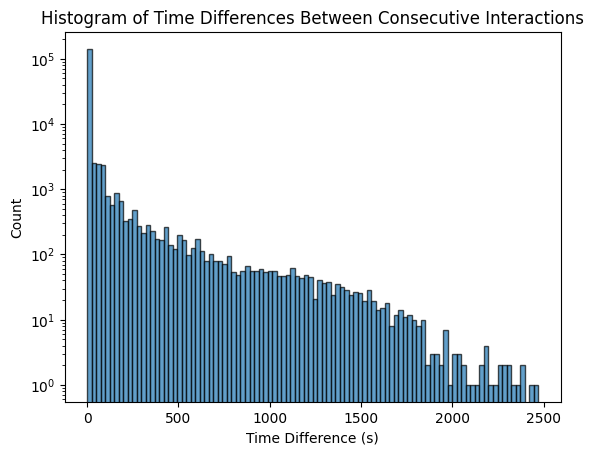

In [19]:
import matplotlib.pyplot as plt


new_attacked_df = new_attacked_df.sort_values(['u', 'ts'])

new_attacked_df['diff'] = new_attacked_df.groupby(['u', 'i'])['ts'].diff().fillna(0)

ts_diffs = new_attacked_df['diff'].dropna()
# ts_diffs

# Calculate statistics
mean_diff = ts_diffs.mean()
median_diff = ts_diffs.median()
std_diff = ts_diffs.std()

plt.hist(ts_diffs/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
plt.ylabel('Count')
plt.xlabel('Time Difference (s)')
plt.title('Histogram of Time Differences Between Consecutive Interactions')

In [37]:
print(orig_df['i'].min())

8228


In [20]:
tspear_path = '/raid/t2/TGN_adv/tspear/DATA/wiki_tspear2'
filename = 'edges.csv'

tspear_df = pd.read_csv(os.path.join(tspear_path, filename))
tspear_df.head()

,Unnamed: 0,src,dst,time,int_roll,ext_roll
0,0,1.0,8228.0,0.0,0,0
1,1,2.0,8229.0,36.0,1,0
2,2,2.0,8229.0,77.0,0,0
3,3,3.0,8230.0,131.0,2,0
4,4,2.0,8229.0,150.0,0,0


In [23]:
def compute_overall_outgoing_degree(E):
    return Counter(E['src'])

node_degree_tspear = compute_overall_outgoing_degree(tspear_df[['src', 'dst']])
node_degree_tspear

Counter({1.0: 3,
         2.0: 311,
         3.0: 179,
         4.0: 238,
         5.0: 754,
         6.0: 386,
         8.0: 49,
         7.0: 377,
         9.0: 407,
         10.0: 82,
         11.0: 128,
         12.0: 7,
         13.0: 343,
         14.0: 176,
         15.0: 57,
         16.0: 20,
         17.0: 119,
         18.0: 648,
         19.0: 259,
         20.0: 2,
         21.0: 3,
         22.0: 10,
         23.0: 153,
         24.0: 8,
         25.0: 200,
         26.0: 72,
         27.0: 14,
         28.0: 411,
         29.0: 14,
         30.0: 3,
         31.0: 6,
         32.0: 9,
         33.0: 1,
         34.0: 35,
         35.0: 7,
         36.0: 12,
         37.0: 501,
         38.0: 3,
         39.0: 3,
         40.0: 317,
         41.0: 247,
         42.0: 23,
         43.0: 66,
         44.0: 46,
         45.0: 63,
         46.0: 46,
         47.0: 129,
         48.0: 386,
         49.0: 136,
         50.0: 43,
         51.0: 200,
         52.0: 363,
         

In [25]:
deg_diff = []
for node, degree in node_degree_orig.items():
    # if node > 8000:
    # print(f'For {node = } original {degree = }, ', end=' ')
    # print(f'In attacked data degree {node_degree_attack.get(node, -np.inf)}')
    deg_diff.append(degree - node_degree_tspear.get(node, 0))

deg_diff = sorted(deg_diff)
print(deg_diff)
print(deg_diff[0])
print(deg_diff[-1])

[-252, -237, -220, -207, -195, -181, -179, -175, -175, -169, -167, -165, -158, -156, -150, -146, -142, -142, -137, -135, -135, -134, -131, -130, -130, -129, -128, -126, -125, -124, -123, -122, -121, -121, -121, -119, -118, -116, -116, -115, -115, -114, -114, -113, -112, -112, -111, -111, -110, -109, -108, -108, -107, -106, -106, -105, -103, -103, -101, -100, -100, -99, -98, -97, -95, -94, -93, -92, -90, -90, -89, -89, -89, -89, -88, -88, -87, -87, -86, -86, -86, -85, -84, -84, -84, -84, -83, -83, -82, -82, -82, -81, -81, -81, -81, -80, -80, -80, -79, -78, -78, -78, -78, -76, -76, -76, -76, -76, -75, -75, -74, -73, -73, -73, -73, -72, -72, -71, -71, -70, -68, -68, -68, -68, -68, -67, -67, -67, -67, -67, -67, -67, -67, -67, -66, -66, -66, -65, -65, -65, -64, -64, -63, -63, -63, -62, -62, -62, -61, -61, -60, -60, -60, -59, -59, -59, -59, -59, -59, -59, -59, -59, -59, -58, -58, -58, -58, -58, -57, -57, -57, -56, -56, -56, -56, -56, -56, -55, -55, -55, -55, -55, -54, -54, -54, -54, -54, -53

In [24]:
max(list(node_degree_check_orig.values()))

282

In [25]:
len(node_degree_check_orig.values())

2744